In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

import pyoscprob.const as const

from tqdm import tqdm

from pyoscprob.oscillation import Oscillator
from pyoscprob.oscillation_parameters import OscillationParameters
from pyoscprob.earth import Slab, Layer

axis_size=15
legend_size=13
tick_size=13

plt.rc('axes',labelsize=axis_size)
plt.rc('legend',fontsize=legend_size)
plt.rc('xtick',labelsize=tick_size)
plt.rc('ytick',labelsize=tick_size)
plt.rc('font',size=legend_size)
plt.rc("figure", figsize=(8, 6))

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

In [2]:
# -----------------------------
# Beam configuration (T2K baseline)
# -----------------------------

L = 295 * u.km
rho = 3.3 * u.g / u.cm**3
Z_over_A = 0.4

beam_layer = Layer("Crust", Rmin=0*u.km, Rmax=L, density=rho, Z_over_A=Z_over_A)
beam_slab = Slab(entry=None, exit=None, thickness=L, layer=beam_layer)
slabs = [beam_slab]

# Oscillation Probabilities

In [3]:
E = np.linspace(0.1, 2, 1000) * u.GeV

# -----------------------------
# Oscillation parameters
# -----------------------------
osc_params = OscillationParameters()
osc = Oscillator(osc_params)

Delta = [-np.pi/2, 0, np.pi/2, np.pi]
Delta_label = [r"$-\pi/2$", r"0", r"$\pi/2$", r"$\pi$"]
MH = [1, -1]
MH_label = ["Normal", "Inverted"]

# -----------------------------
# Vectorized arrays for probabilities
# -----------------------------
p_mu_e = np.zeros((len(MH), len(Delta), len(E)))
p_mu_e_anti = np.zeros((len(MH), len(Delta), len(E)))

# -----------------------------
# Compute probabilities
# -----------------------------
for i, mh in enumerate(MH):
    osc.osc.hierarchy = mh
    for j, delta in enumerate(Delta):
        osc.osc.deltaCP = delta

        probs = osc.probabilities("mu", slabs, E, anti=False)
        p_mu_e[i,j,:] = probs["e"]

        probs_anti = osc.probabilities("mu", slabs, E, anti=True)
        p_mu_e_anti[i,j,:] = probs_anti["e"]



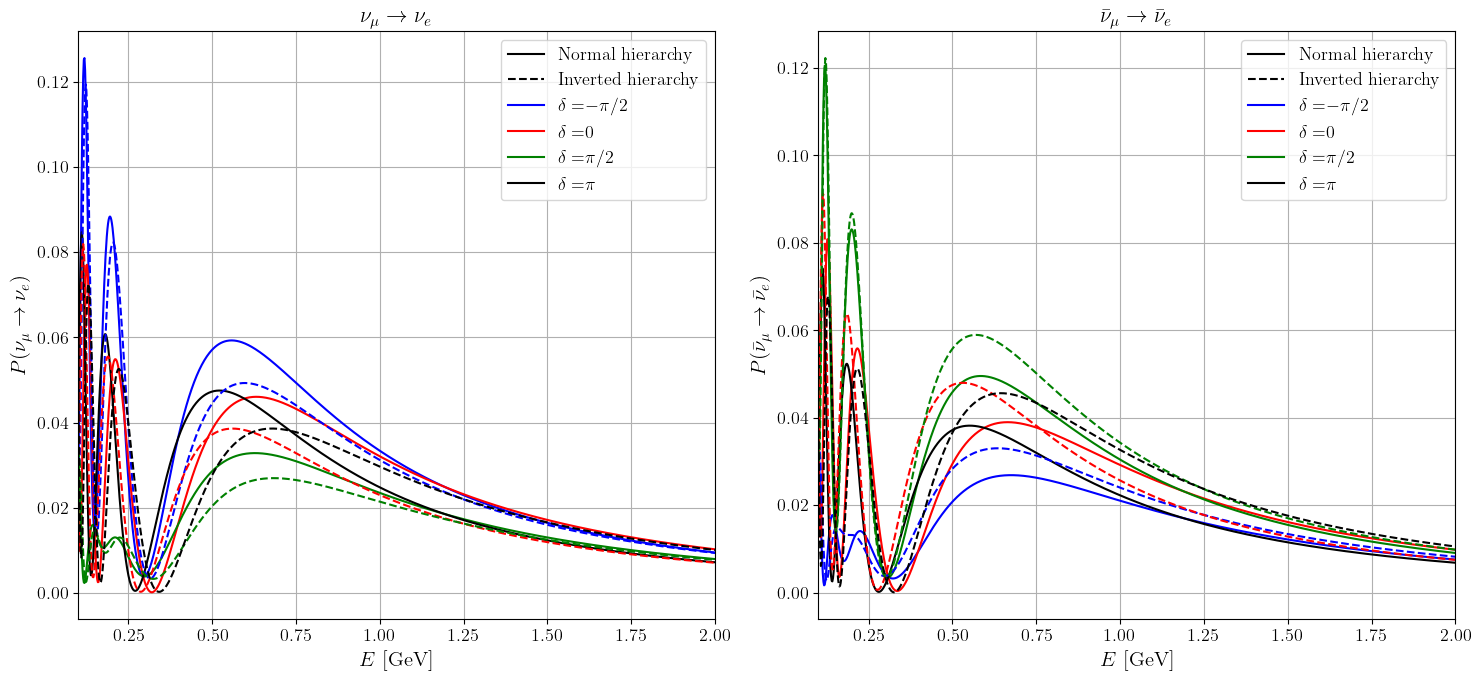

In [4]:
# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1,2, figsize=(15,7))

ls = ['-', '--']
colors = ['b', 'r', 'g', 'k']

# ---- nu_mu -> nu_e ----
ax = axes[0]
for i, mh in enumerate(MH):
    for j, delta in enumerate(Delta):
        ax.plot(E, p_mu_e[i,j], ls=ls[i], color=colors[j])

# Legend placeholders
for i, mh_label in enumerate(MH_label):
    ax.plot([], [], ls=ls[i], color='k', label=f'{mh_label} hierarchy')
for i, delta_label in enumerate(Delta_label):
    ax.plot([], [], ls='-', color=colors[i], label=r'$\delta =$' + delta_label)

ax.set_xlim(E[0].value, E[-1].value)
ax.set_xlabel(r'$E$ [GeV]')
ax.set_ylabel(r'$P(\nu_\mu \rightarrow \nu_e)$')
ax.set_title(r'$\nu_\mu \rightarrow \nu_e$')
ax.legend()
ax.grid()

# ---- anti-nu_mu -> anti-nu_e ----
ax = axes[1]
for i, mh in enumerate(MH):
    for j, delta in enumerate(Delta):
        ax.plot(E, p_mu_e_anti[i,j], ls=ls[i], color=colors[j])

# Legend placeholders
for i, mh_label in enumerate(MH_label):
    ax.plot([], [], ls=ls[i], color='k', label=f'{mh_label} hierarchy')
for i, delta_label in enumerate(Delta_label):
    ax.plot([], [], ls='-', color=colors[i], label=r'$\delta =$' + delta_label)

ax.set_xlim(E[0].value, E[-1].value)
ax.set_xlabel(r'$E$ [GeV]')
ax.set_ylabel(r'$P(\bar{\nu}_\mu \rightarrow \bar{\nu}_e)$')
ax.set_title(r'$\bar{\nu}_\mu \rightarrow \bar{\nu}_e$')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Degeneracies

## $\delta_\mathrm{CP}$ vs MO

In [5]:
E = 600*u.MeV

osc_param = OscillationParameters()
osc = Oscillator(osc_param)



Delta = np.linspace(-np.pi, np.pi, 100)

p_mu_e = {'NH': np.zeros(len(Delta)), 'IH': np.zeros(len(Delta)), 'anti_NH': np.zeros(len(Delta)), 'anti_IH': np.zeros(len(Delta))}

for i, delta in tqdm(enumerate(Delta)) :

    # Normal Hierarchy
    osc.osc.hierarchy = 1
    osc.osc.deltaCP = delta
    probs = osc.probabilities("mu", slabs, E, anti=False)
    p_mu_e['NH'][i] = probs["e"]
    probs_anti = osc.probabilities("mu", slabs, E, anti=True)
    p_mu_e['anti_NH'][i] = np.abs(probs_anti["e"])

    # Inverted Hierarchy
    osc.osc.hierarchy = -1
    osc.osc.deltaCP = delta
    probs = osc.probabilities("mu", slabs, E, anti=False)
    p_mu_e['IH'][i] = np.abs(probs["e"])
    probs_anti = osc.probabilities("mu", slabs, E, anti=True)
    p_mu_e['anti_IH'][i] = np.abs(probs_anti["e"])


100it [00:00, 566.61it/s]


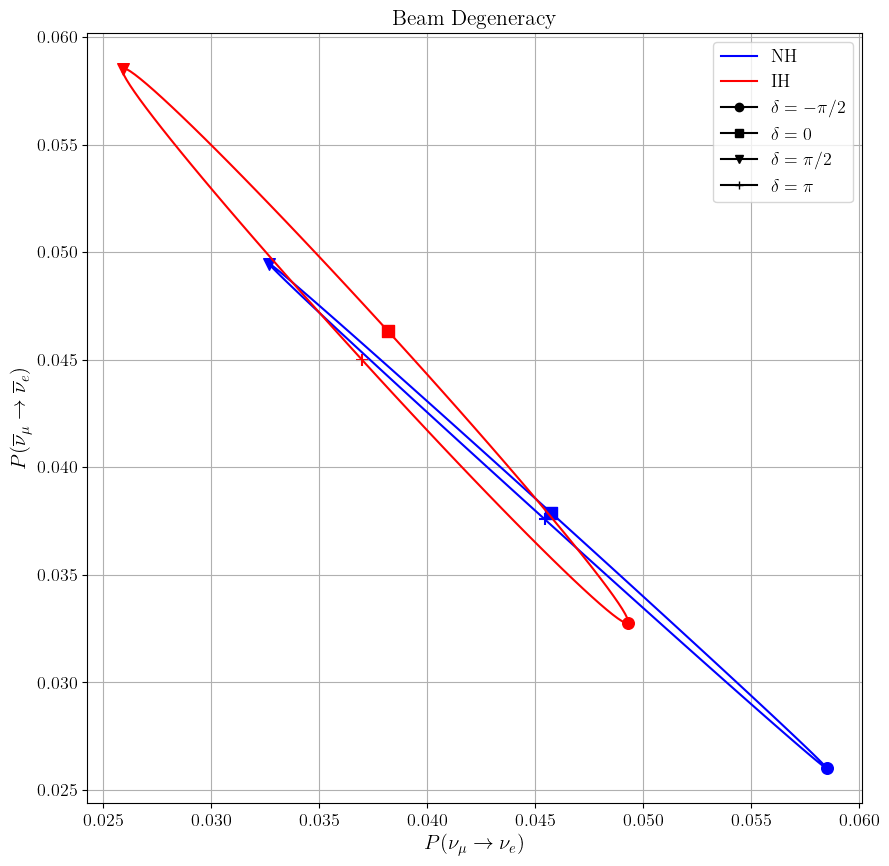

In [7]:
plt.figure(figsize=(10, 10))

plt.plot(p_mu_e['NH'], p_mu_e['anti_NH'], label='NH', color='b')
plt.plot(p_mu_e['IH'], p_mu_e['anti_IH'], label='IH', color='r')

# interpolate special delta values

delta_CP = np.array([-np.pi/2, 0, np.pi/2, np.pi])
delta_label = [r"-\pi/2", r"0", r"\pi/2", r"\pi"]
markers = ['o', 's', 'v', '+']

for delta, marker in zip(delta_CP, markers) :
    for mh, anti_mh, color in zip(['NH', 'IH'], ['anti_NH', 'anti_IH'], ['blue', 'red']) :

        p_mu_e_interp = np.interp(delta, Delta, p_mu_e[mh])
        p_mu_e_anti_interp = np.interp(delta, Delta, p_mu_e[anti_mh])
        plt.scatter(p_mu_e_interp, p_mu_e_anti_interp, marker=marker, color=color, s=70)

for marker, label in zip(markers, delta_label) :
    plt.plot([], [], color='k', marker=marker, label=r"$\delta = " + label + r"$")


plt.xlabel(r'$P(\nu_\mu \rightarrow \nu_e)$')
plt.ylabel(r'$P(\overline{\nu}_\mu \rightarrow \overline{\nu}_e)$')
plt.legend()
plt.title("Beam Degeneracy")
plt.grid()

plt.show()